In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split

In [34]:
df_movies = pd.read_csv('archive1/archive/movies_metadata.csv', sep=',', na_values=[''], quotechar='"', low_memory=False)
df_ratings = pd.read_csv('archive1/archive/ratings_small.csv')

def safe_parse(val):
    if pd.isna(val) or val == '' or val == '[]' or val == '{}':
        return None
    try:
        return ast.literal_eval(val)
    except:
        try:
            return json.loads(val)
        except:
            return None

df_movies['id'] = pd.to_numeric(df_movies['id'], errors='coerce')
df_movies = df_movies.dropna(subset=['id']).copy()
df_movies['id'] = df_movies['id'].astype(int)

df_ratings['movieId'] = pd.to_numeric(df_ratings['movieId'], errors='coerce')
df_ratings = df_ratings.dropna(subset=['movieId']).copy()
df_ratings['movieId'] = df_ratings['movieId'].astype(int)

valid_movie_ids = df_ratings['movieId'].unique()
df_movies = df_movies[df_movies['id'].isin(valid_movie_ids)].copy()

df_movies['belongs_to_collection_parsed'] = df_movies['belongs_to_collection'].apply(safe_parse)
df_movies['genres_parsed'] = df_movies['genres'].apply(safe_parse)
df_movies['has_collection'] = df_movies['belongs_to_collection_parsed'].apply(
    lambda x: 1 if isinstance(x, dict) and x.get('name') else 0
)
df_movies['genre_list'] = df_movies['genres_parsed'].apply(
    lambda x: [g['name'] for g in x] if isinstance(x, list) else []
)
mlb_genres = MultiLabelBinarizer()
genres_onehot = mlb_genres.fit_transform(df_movies['genre_list'])
genres_df = pd.DataFrame(genres_onehot, columns=mlb_genres.classes_, index=df_movies.index)

df_movies['production_companies_parsed'] = df_movies['production_companies'].apply(safe_parse)
def extract_company_names(x):
    if isinstance(x, list):
        return [comp.get('name', '') for comp in x if isinstance(comp, dict) and comp.get('name')]
    return []
df_movies['company_list'] = df_movies['production_companies_parsed'].apply(extract_company_names)
all_companies = df_movies['company_list'].explode()
top_companies = all_companies.value_counts().head(20).index.tolist()
def keep_top_companies(companies):
    return [c for c in companies if c in top_companies] or ['other']
df_movies['company_list_top'] = df_movies['company_list'].apply(keep_top_companies)
mlb_companies = MultiLabelBinarizer()
companies_onehot = mlb_companies.fit_transform(df_movies['company_list_top'])
companies_df = pd.DataFrame(companies_onehot, columns=mlb_companies.classes_, index=df_movies.index)

df_movies['production_countries_parsed'] = df_movies['production_countries'].apply(safe_parse)
def extract_country_names(x):
    if isinstance(x, list):
        return [cnt.get('name', '') for cnt in x if isinstance(cnt, dict) and cnt.get('name')]
    return []
df_movies['country_list'] = df_movies['production_countries_parsed'].apply(extract_country_names)
all_countries = df_movies['country_list'].explode()
top_countries = all_countries.value_counts().head(10).index.tolist()
def keep_top_countries(countries):
    return [c for c in countries if c in top_countries] or ['other']
df_movies['country_list_top'] = df_movies['country_list'].apply(keep_top_countries)
mlb_countries = MultiLabelBinarizer()
countries_onehot = mlb_countries.fit_transform(df_movies['country_list_top'])
countries_df = pd.DataFrame(countries_onehot, columns=mlb_countries.classes_, index=df_movies.index)

df_movies['original_language'] = df_movies['original_language'].fillna('unknown')
top_languages = df_movies['original_language'].value_counts().head(10).index.tolist()
df_movies['language_top'] = df_movies['original_language'].apply(
    lambda x: x if x in top_languages else 'other'
)
lang_onehot = pd.get_dummies(df_movies['language_top'], prefix='lang').astype(int)

df_movies['adult'] = df_movies['adult'].apply(lambda x: 1 if str(x).lower() == 'true' else 0)
df_movies['release_date'] = pd.to_datetime(df_movies['release_date'], errors='coerce')
df_movies['release_year'] = df_movies['release_date'].dt.year.fillna(0).astype(int)
df_movies['runtime'] = pd.to_numeric(df_movies['runtime'], errors='coerce').fillna(0)
df_movies['popularity'] = pd.to_numeric(df_movies['popularity'], errors='coerce').fillna(0)
df_movies['budget'] = pd.to_numeric(df_movies['budget'], errors='coerce').fillna(0)
df_movies['revenue'] = pd.to_numeric(df_movies['revenue'], errors='coerce').fillna(0)

df_movies['tagline'] = df_movies['tagline'].fillna('')
df_movies['full_text'] = df_movies['overview'].fillna('') + ' ' + df_movies['tagline']

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_movies['full_text'])

numeric_cols = ['has_collection', 'adult', 'vote_average', 'vote_count',
                'runtime', 'release_year', 'popularity', 'budget', 'revenue']
numeric_cols = [col for col in numeric_cols if col in df_movies.columns]

dense_features = pd.concat([
    df_movies[numeric_cols].reset_index(drop=True),
    genres_df.reset_index(drop=True),
    companies_df.reset_index(drop=True),
    countries_df.reset_index(drop=True),
    lang_onehot.reset_index(drop=True)
], axis=1)

print(dense_features.head(10))

   has_collection  adult  vote_average  vote_count  runtime  release_year  \
0               0      0           7.7      1886.0    170.0          1995   
1               1      0           6.6      1194.0    130.0          1995   
2               0      0           5.7       137.0    119.0          1995   
3               0      0           7.8      1343.0    178.0          1995   
4               0      0           7.2       364.0    136.0          1995   
5               0      0           6.5       539.0     98.0          1995   
6               1      0           6.4       305.0    105.0          1995   
7               0      0           7.1       365.0    112.0          1995   
8               0      0           7.6       308.0    108.0          1995   
9               0      0           7.4      2470.0    129.0          1995   

   popularity    budget      revenue  Action  ...  lang_en  lang_es  lang_fr  \
0   17.924927  60000000  187436818.0       1  ...        1        0     

In [35]:
print(dense_features.columns.tolist())

['has_collection', 'adult', 'vote_average', 'vote_count', 'runtime', 'release_year', 'popularity', 'budget', 'revenue', 'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western', 'Amblin Entertainment', 'Canal+', 'Columbia Pictures', 'Columbia Pictures Corporation', 'Dimension Films', 'DreamWorks SKG', 'Metro-Goldwyn-Mayer (MGM)', 'Miramax Films', 'New Line Cinema', 'Orion Pictures', 'Paramount Pictures', 'Regency Enterprises', 'Touchstone Pictures', 'TriStar Pictures', 'Twentieth Century Fox Film Corporation', 'United Artists', 'Universal Pictures', 'Village Roadshow Pictures', 'Warner Bros.', 'Working Title Films', 'other', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'Netherlands', 'Spain', 'Sweden', 'United Kingdom', 'United States of America', 'other', 'lang_de', 'lang_en', 'lang_es', 'lang_fr', 'lang_it', 'lang_ja

In [36]:
pivot = df_ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)
pivot = pivot.fillna(0)
print(pivot.head(10))

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           0.0     0.0     4.0     0.0     0.0     0.0     0.0     0.0   
6           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
7           3.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
8           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
9           4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
10          0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  9       10      ...  161084  161155  161594  161830  161918  161944  \
userId             

In [37]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(pivot)
print(similarity)

[[1.         0.         0.         ... 0.06291708 0.         0.01746565]
 [0.         1.         0.12429498 ... 0.02413984 0.17059464 0.1131753 ]
 [0.         0.12429498 1.         ... 0.08098382 0.13660585 0.17019275]
 ...
 [0.06291708 0.02413984 0.08098382 ... 1.         0.04260878 0.08520194]
 [0.         0.17059464 0.13660585 ... 0.04260878 1.         0.22867673]
 [0.01746565 0.1131753  0.17019275 ... 0.08520194 0.22867673 1.        ]]


In [46]:
user_means = pivot.mean(axis=1)
pivot_norm = pivot.sub(user_means, axis=0)

user_similarity_norm = cosine_similarity(pivot_norm)

def predict_user_based(user_id, movie_id, pivot_norm, user_means, similarity, top_k=10, alpha=5):
    user_idx = pivot.index.get_loc(user_id)
    movie_idx = pivot.columns.get_loc(movie_id)

    ratings_norm = pivot_norm.iloc[:, movie_idx].values
    sim = similarity[user_idx, :].copy()
    sim[user_idx] = 0

    non_zero = ratings_norm != 0
    valid_idx = np.where(non_zero)[0]
    valid_sim = sim[valid_idx]
    valid_ratings = ratings_norm[valid_idx]

    if len(valid_sim) == 0:
        return user_means[user_id]

    user_ratings_bool = (pivot.iloc[user_idx, :] != 0).astype(int).values
    neighbor_ratings_bool = (pivot.iloc[valid_idx, :] != 0).astype(int).values
    common_counts = np.dot(neighbor_ratings_bool, user_ratings_bool)
    weights = valid_sim * (common_counts / (common_counts + alpha))

    if top_k is not None and top_k < len(weights):
        top_indices = np.argsort(-weights)[:top_k]
        weights = weights[top_indices]
        valid_ratings = valid_ratings[top_indices]

    if np.sum(weights) == 0:
        return user_means[user_id]

    pred_norm = np.dot(weights, valid_ratings) / np.sum(weights)
    return user_means[user_id] + pred_norm

user_ex = 5
movie_ex = 100
pred_user = predict_user_based(user_ex, movie_ex, pivot_norm, user_means, user_similarity_norm, top_k=10)
print(f"[User‑based] Предсказание: {pred_user:.2f}")

[User‑based] Предсказание: -0.11


In [52]:
pivot_norm = pivot.sub(user_means, axis=0)
pivot_items_norm = pivot_norm.T

item_similarity_collab_norm = cosine_similarity(pivot_items_norm)
movie_rating_counts = (pivot != 0).sum(axis=0).values

def predict_item_collab_normalized(user_id, movie_id, pivot, pivot_norm, user_means,
                                   item_sim, top_k=10, alpha=5):
    if user_id not in pivot.index or movie_id not in pivot.columns:
        return user_means.get(user_id, 3.0)

    user_idx = pivot.index.get_loc(user_id)
    movie_idx = pivot.columns.get_loc(movie_id)

    user_ratings_norm = pivot_norm.iloc[user_idx, :].values
    sim = item_sim[movie_idx, :].copy()
    sim[movie_idx] = 0

    rated_mask = user_ratings_norm != 0
    valid_idx = np.where(rated_mask)[0]
    valid_sim = sim[valid_idx]
    valid_ratings_norm = user_ratings_norm[valid_idx]

    if len(valid_sim) == 0:
        return user_means.iloc[user_idx]

    target_movie_bool = (pivot.iloc[:, movie_idx] != 0).astype(int).values
    neighbor_movies_bool = (pivot.iloc[:, valid_idx] != 0).astype(int).values
    common_counts = np.dot(target_movie_bool, neighbor_movies_bool)

    weights = valid_sim * (common_counts / (common_counts + alpha))

    if top_k is not None and top_k < len(weights):
        top_indices = np.argsort(-weights)[:top_k]
        weights = weights[top_indices]
        valid_ratings_norm = valid_ratings_norm[top_indices]

    if np.sum(weights) == 0:
        return user_means.iloc[user_idx]

    pred_norm = np.dot(weights, valid_ratings_norm) / np.sum(weights)
    return user_means.iloc[user_idx] + pred_norm

pred_item_collab_norm = predict_item_collab_normalized(
    user_ex, movie_ex, pivot, pivot_norm, user_means,
    item_similarity_collab_norm, top_k=10, alpha=5
)
print(f"[Item‑based collaborative (норм.+баланс)]: {pred_item_collab_norm:.2f}")

[Item‑based collaborative (норм.+баланс)]: 0.00


In [53]:
movie_ids = df_movies['id'].values

num_df = df_movies[numeric_cols].copy()
num_df.index = movie_ids

genres_df.index = movie_ids
companies_df.index = movie_ids
countries_df.index = movie_ids
lang_onehot.index = movie_ids

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=movie_ids)

scaler = StandardScaler()
num_scaled = scaler.fit_transform(num_df)
num_scaled_df = pd.DataFrame(num_scaled, columns=num_df.columns, index=num_df.index)

svd = TruncatedSVD(n_components=100, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_df)
tfidf_reduced_df = pd.DataFrame(tfidf_reduced, index=tfidf_df.index,
                                columns=[f'tfidf_svd_{i}' for i in range(tfidf_reduced.shape[1])])

all_features = pd.concat([
    num_scaled_df,
    genres_df,
    companies_df,
    countries_df,
    lang_onehot,
    tfidf_reduced_df
], axis=1)

common_ids = all_features.index.intersection(pivot.columns)
print(f"Количество общих фильмов: {len(common_ids)}")

Количество общих фильмов: 2830


In [54]:
all_features_common = all_features.loc[common_ids]
pivot_common = pivot[common_ids]

all_features_sorted = all_features_common.loc[pivot_common.columns]

content_similarity = cosine_similarity(all_features_sorted)
user_rating_counts = (pivot_common != 0).sum(axis=1).values

def predict_item_content_normalized(user_id, movie_id, pivot_common, pivot_norm_common,
                                    user_means_common, content_sim, top_k=10, alpha=5):
    if user_id not in pivot_common.index or movie_id not in pivot_common.columns:
        return user_means_common.get(user_id, 3.0)

    user_idx = pivot_common.index.get_loc(user_id)
    movie_idx = pivot_common.columns.get_loc(movie_id)

    user_ratings_norm = pivot_norm_common.iloc[user_idx, :].values
    sim = content_sim[movie_idx, :].copy()
    sim[movie_idx] = 0

    rated_mask = user_ratings_norm != 0
    valid_idx = np.where(rated_mask)[0]
    valid_sim = sim[valid_idx]
    valid_ratings_norm = user_ratings_norm[valid_idx]

    if len(valid_sim) == 0:
        return user_means_common.iloc[user_idx]

    user_count = user_rating_counts[user_idx]
    weight_factor = user_count / (user_count + alpha)
    weights = valid_sim * weight_factor

    if top_k is not None and top_k < len(weights):
        top_indices = np.argsort(-weights)[:top_k]
        weights = weights[top_indices]
        valid_ratings_norm = valid_ratings_norm[top_indices]

    if np.sum(weights) == 0:
        return user_means_common.iloc[user_idx]

    pred_norm = np.dot(weights, valid_ratings_norm) / np.sum(weights)
    return user_means_common.iloc[user_idx] + pred_norm

pivot_common = pivot[common_ids]
pivot_norm_common = pivot_norm[common_ids]
user_means_common = user_means.loc[pivot_common.index]

pred_item_content_norm = predict_item_content_normalized(
    user_ex, movie_ex, pivot_common, pivot_norm_common, user_means_common,
    content_similarity, top_k=10, alpha=5
)
print(f"[Item‑based content (норм.+баланс)]: {pred_item_content_norm:.2f}")

[Item‑based content (норм.+баланс)]: 0.46


In [55]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df_ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

algo = SVD(n_factors=100, reg_all=0.02, lr_all=0.005, random_state=42)
algo.fit(trainset)

predictions = algo.test(testset)
rmse = accuracy.rmse(predictions)
print(f"[SVD] RMSE на тесте: {rmse:.4f}")

pred_svd = algo.predict(uid=user_ex, iid=movie_ex)
print(f"[SVD] Предсказание: {pred_svd.est:.2f}")

RMSE: 0.9024
[SVD] RMSE на тесте: 0.9024
[SVD] Предсказание: 3.46


In [58]:
print("\n--- Сводка предсказаний для пользователя {} и фильма {} ---".format(user_ex, movie_ex))
print(f"User‑based (норм.+баланс): {pred_user:.2f}")
print(f"Item‑based collaborative (норм.+баланс): {pred_item_collab_norm:.2f}")
print(f"Item‑based content (норм.+баланс): {pred_item_content_norm:.2f}")
print(f"Matrix Factorization (SVD): {pred_svd.est:.2f}")


--- Сводка предсказаний для пользователя 5 и фильма 100 ---
User‑based (норм.+баланс): -0.11
Item‑based collaborative (норм.+баланс): 0.00
Item‑based content (норм.+баланс): 0.46
Matrix Factorization (SVD): 3.46


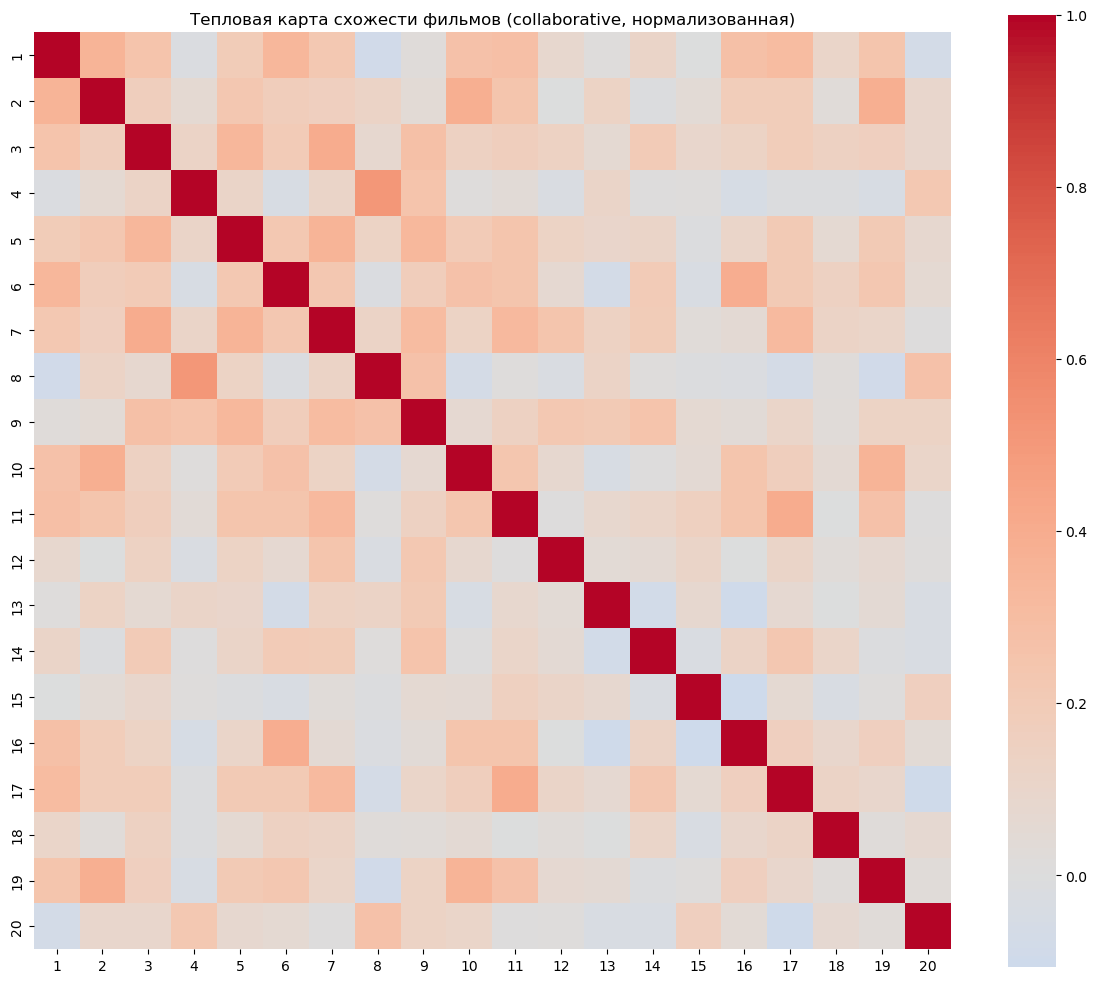

In [59]:
n_show = 20
sim_matrix = item_similarity_collab_norm[:n_show, :n_show]
labels = pivot.columns[:n_show].astype(str)

plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, xticklabels=labels, yticklabels=labels,
            cmap='coolwarm', center=0, annot=False, square=True)
plt.title('Тепловая карта схожести фильмов (collaborative, нормализованная)')
plt.tight_layout()
plt.show()

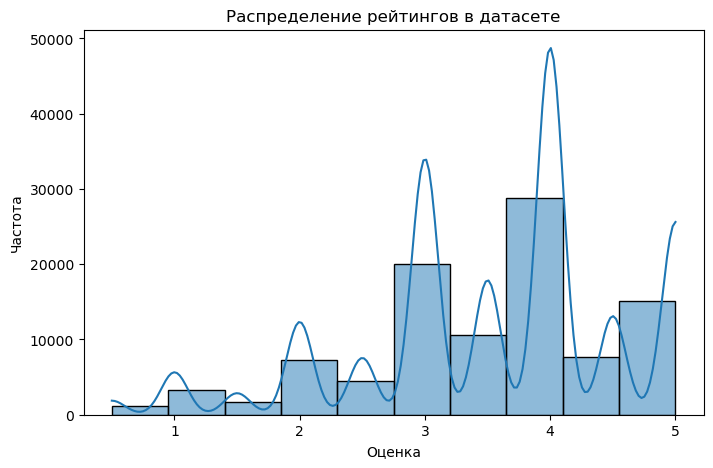

In [62]:
plt.figure(figsize=(8, 5))
sns.histplot(df_ratings['rating'], bins=10, kde=True)
plt.title('Распределение рейтингов в датасете')
plt.xlabel('Оценка')
plt.ylabel('Частота')
plt.show()

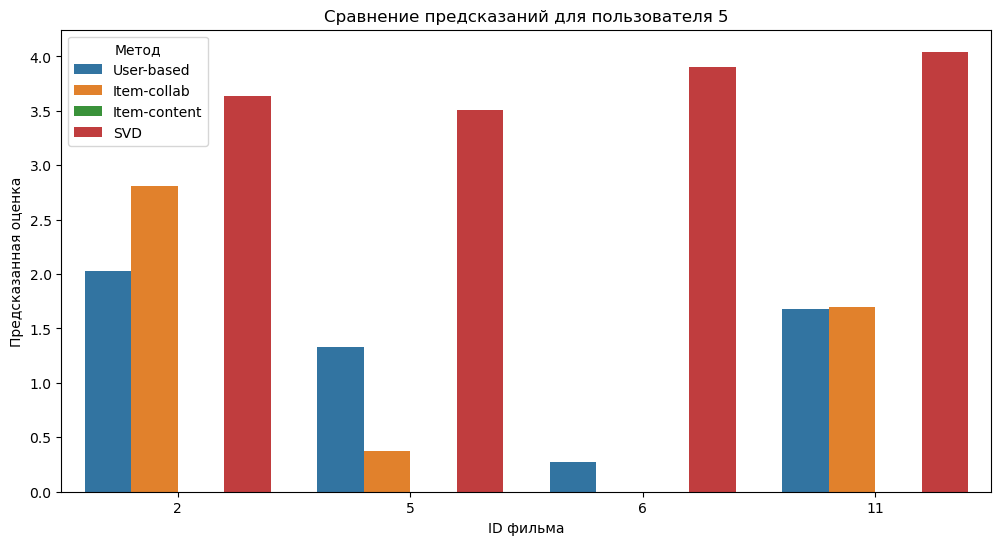

In [67]:
user_ratings = pivot.loc[user_ex]
unrated_movies = user_ratings[user_ratings == 0].index[:10]

preds_user_based = []
preds_item_collab = []
preds_item_content = []
preds_svd = []

for movie in unrated_movies:
    preds_user_based.append(predict_user_based(user_ex, movie, pivot_norm, user_means, user_similarity_norm, top_k=10))
    preds_item_collab.append(predict_item_collab_normalized(user_ex, movie, pivot, pivot_norm,
                                                            user_means, item_similarity_collab_norm, top_k=10))
    if movie in pivot_common.columns:
        preds_item_content.append(predict_item_content_normalized(user_ex, movie, pivot_common, pivot_norm_common,
                                                                  user_means_common, content_similarity, top_k=10))
    else:
        preds_item_content.append(None)
    preds_svd.append(algo.predict(uid=user_ex, iid=movie).est)

df_preds = pd.DataFrame({
    'movieId': unrated_movies,
    'User-based': preds_user_based,
    'Item-collab': preds_item_collab,
    'Item-content': preds_item_content,
    'SVD': preds_svd
})

df_preds = df_preds.dropna()

df_melted = df_preds.melt(id_vars='movieId', var_name='Method', value_name='Predicted Rating')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='movieId', y='Predicted Rating', hue='Method')
plt.title(f'Сравнение предсказаний для пользователя {user_ex}')
plt.xlabel('ID фильма')
plt.ylabel('Предсказанная оценка')
plt.legend(title='Метод')
plt.show()

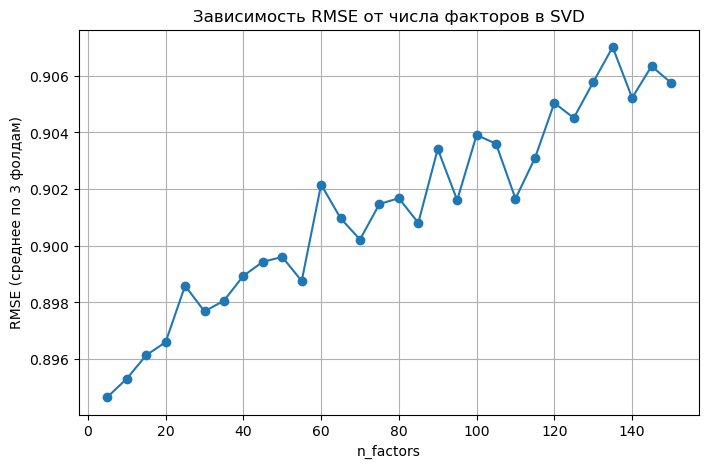

In [74]:
from surprise.model_selection import cross_validate

n_factors_list = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105,
                  110, 115, 120, 125, 130, 135, 140, 145, 150]
rmse_scores = []

for n in n_factors_list:
    algo = SVD(n_factors=n, random_state=42)
    results = cross_validate(algo, data, measures=['RMSE'], cv=3, verbose=False)
    rmse_scores.append(results['test_rmse'].mean())

plt.figure(figsize=(8, 5))
plt.plot(n_factors_list, rmse_scores, marker='o')
plt.title('Зависимость RMSE от числа факторов в SVD')
plt.xlabel('n_factors')
plt.ylabel('RMSE (среднее по 3 фолдам)')
plt.grid()
plt.show()

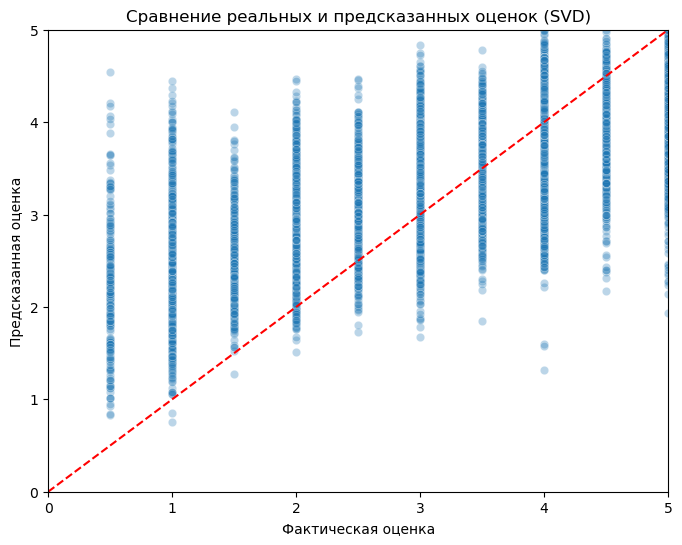

In [72]:
predictions = algo.test(testset)

actual = [pred.r_ui for pred in predictions]
predicted = [pred.est for pred in predictions]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=predicted, alpha=0.3)
plt.plot([0, 5], [0, 5], 'r--')
plt.xlabel('Фактическая оценка')
plt.ylabel('Предсказанная оценка')
plt.title('Сравнение реальных и предсказанных оценок (SVD)')
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.show()